# MLOps Showcase — Modelo de Detecção de Anomalias
Isolation Forest aplicado às métricas AWS CloudWatch

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

DATA_FEATURES = '../data/features/'
MODELS_PATH   = '../models/training/'
os.makedirs(MODELS_PATH, exist_ok=True)
print('Libs carregadas!')

Libs carregadas!


In [10]:
df = pd.read_csv(DATA_FEATURES + 'features_cloudwatch.csv', parse_dates=['timestamp'])
df.set_index('timestamp', inplace=True)
print(f'Shape: {df.shape}')
print(f'Anomalias (zscore): {df["anomalia_zscore"].sum()} ({df["anomalia_zscore"].mean()*100:.2f}%)')
df.head()

Shape: (67349, 12)
Anomalias (zscore): 905 (1.34%)


,value,rolling_mean_12,rolling_std_12,rolling_mean_24,rolling_std_24,diff_1,diff_12,hora,dia_semana,zscore,anomalia_zscore,metrica
timestamp,,,,,,,,,,,,
2014-02-14 16:25:00,0.066,0.128167,0.034656,0.125250,0.030244,-0.068,0.000,16,4,-0.636022,0,ec2_cpu_utilization_24ae8d
2014-02-14 16:30:00,0.134,0.128333,0.034681,0.125333,0.030266,0.068,0.002,16,4,0.081180,0,ec2_cpu_utilization_24ae8d
2014-02-14 16:35:00,0.134,0.122667,0.026026,0.125333,0.030266,0.000,-0.068,16,4,0.081180,0,ec2_cpu_utilization_24ae8d
2014-02-14 16:40:00,0.066,0.122500,0.026411,0.122500,0.032519,-0.068,-0.002,16,4,-0.636022,0,ec2_cpu_utilization_24ae8d
2014-02-14 16:45:00,0.134,0.122500,0.026411,0.122500,0.032519,0.068,0.000,16,4,0.081180,0,ec2_cpu_utilization_24ae8d


In [11]:
FEATURES = ['value', 'rolling_mean_12', 'rolling_std_12',
            'rolling_mean_24', 'rolling_std_24',
            'diff_1', 'diff_12', 'hora', 'dia_semana', 'zscore']

X = df[FEATURES].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Features para treino: {FEATURES}')
print(f'Shape X: {X_scaled.shape}')

Features para treino: ['value', 'rolling_mean_12', 'rolling_std_12', 'rolling_mean_24', 'rolling_std_24', 'diff_1', 'diff_12', 'hora', 'dia_semana', 'zscore']
Shape X: (67349, 10)


In [12]:
modelo = IsolationForest(
    n_estimators=100,
    contamination=0.02,
    random_state=42,
    n_jobs=-1
)

modelo.fit(X_scaled)
print('Modelo treinado!')

df['anomalia_modelo'] = modelo.predict(X_scaled)
df['anomalia_modelo'] = (df['anomalia_modelo'] == -1).astype(int)
df['score_anomalia']  = modelo.score_samples(X_scaled)

print(f'Anomalias detectadas pelo modelo: {df["anomalia_modelo"].sum()} ({df["anomalia_modelo"].mean()*100:.2f}%)')

Modelo treinado!
Anomalias detectadas pelo modelo: 1347 (2.00%)


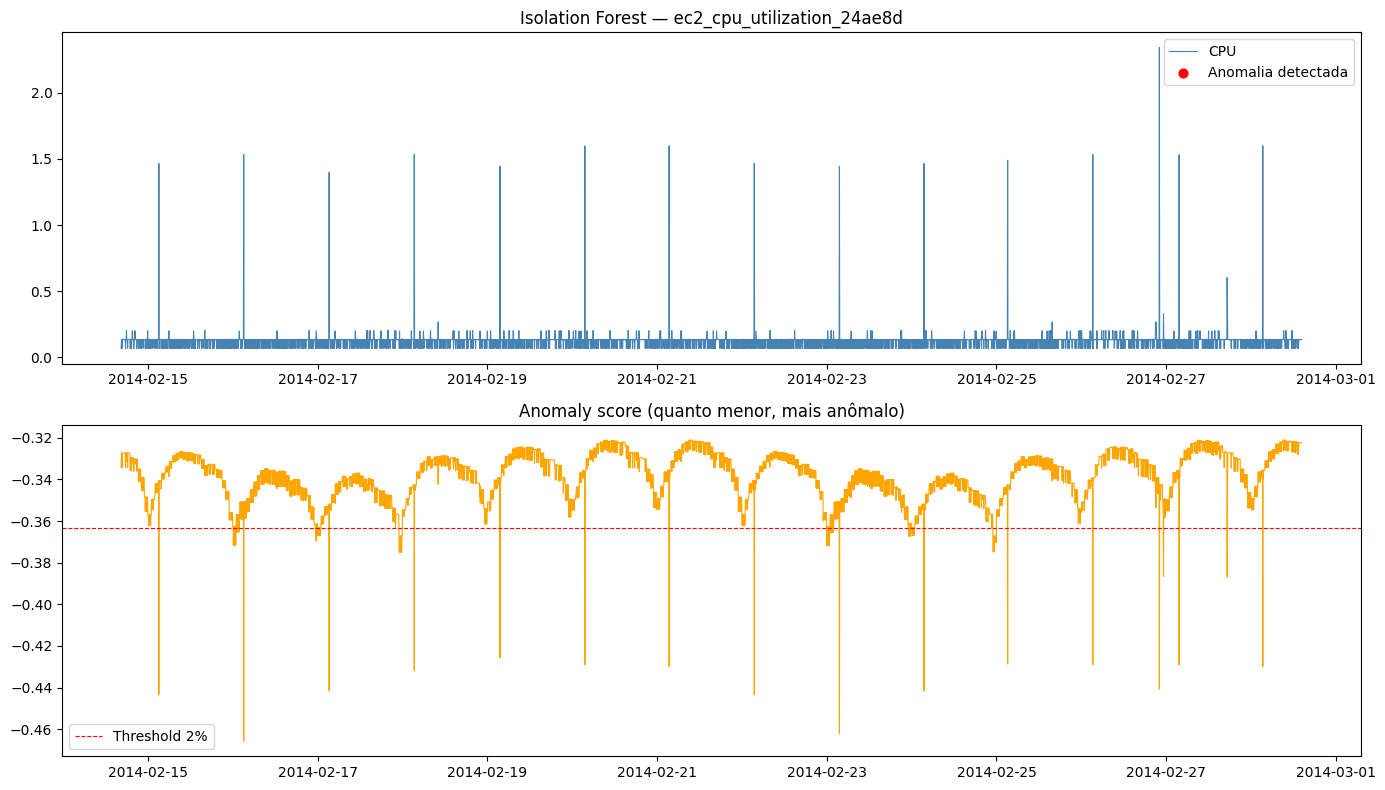

Gráfico salvo!


In [14]:
metrica = 'ec2_cpu_utilization_24ae8d'
df_ex   = df[df['metrica'] == metrica].copy()
df_ex   = df_ex.reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(df_ex['timestamp'], df_ex['value'], color='steelblue', linewidth=0.8, label='CPU')
an = df_ex[df_ex['anomalia_modelo'] == 1]
axes[0].scatter(an['timestamp'], an['value'], color='red', s=40, zorder=5, label='Anomalia detectada')
axes[0].set_title(f'Isolation Forest — {metrica}')
axes[0].legend()

axes[1].plot(df_ex['timestamp'], df_ex['score_anomalia'], color='orange', linewidth=0.8)
axes[1].set_title('Anomaly score (quanto menor, mais anômalo)')
axes[1].axhline(df_ex['score_anomalia'].quantile(0.02), color='red',
                linestyle='--', linewidth=0.8, label='Threshold 2%')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/isolation_forest_resultado.png', dpi=150)
plt.show()
print('Gráfico salvo!')

In [15]:
joblib.dump(modelo,  MODELS_PATH + 'isolation_forest.joblib')
joblib.dump(scaler,  MODELS_PATH + 'scaler.joblib')
joblib.dump(FEATURES, MODELS_PATH + 'features.joblib')

print('Modelo salvo em:')
print(f'  {MODELS_PATH}isolation_forest.joblib')
print(f'  {MODELS_PATH}scaler.joblib')
print(f'  {MODELS_PATH}features.joblib')

resumo = df.groupby('metrica')['anomalia_modelo'].agg(['sum','count'])
resumo['pct_anomalia'] = (resumo['sum'] / resumo['count'] * 100).round(2)
resumo.columns = ['anomalias', 'total', 'pct_%']
print('\nResumo por métrica:')
print(resumo.sort_values('pct_%', ascending=False))

Modelo salvo em:
  ../models/training/isolation_forest.joblib
  ../models/training/scaler.joblib
  ../models/training/features.joblib

Resumo por métrica:
                                    anomalias  total  pct_%
metrica                                                    
ec2_disk_write_bytes_c0d644               895   4009  22.32
ec2_disk_write_bytes_1ef3de               441   4707   9.37
iio_us-east-1_i-a2eb1cd9_NetworkIn          8   1220   0.66
ec2_network_in_257a54                       3   4009   0.07
ec2_cpu_utilization_24ae8d                  0   4009   0.00
ec2_cpu_utilization_825cc2                  0   4009   0.00
ec2_cpu_utilization_53ea38                  0   4009   0.00
ec2_cpu_utilization_77c1ca                  0   4009   0.00
ec2_cpu_utilization_5f5533                  0   4009   0.00
ec2_cpu_utilization_fe7f93                  0   4009   0.00
ec2_cpu_utilization_c6585a                  0   4009   0.00
ec2_cpu_utilization_ac20cd                  0   4009   0.00
ec2_n